# Lattice Boltzmann: Validation (Phase 1)

Validates `lattice.py`'s D2Q9 BGK core two ways:

1. **Conservation**: pure collide+stream on a periodic domain must
   conserve total mass and momentum exactly (both are linear invariants
   of the BGK collision operator by construction, and streaming just
   permutes values around a periodic grid).
2. **Chapman-Enskog viscosity**: a sinusoidal shear wave decays under
   viscous diffusion at rate `nu*k^2` (from the linearized, pressure
   -free Navier-Stokes momentum equation). Fitting the decay rate from
   the simulation and comparing to the analytic `nu = (tau-1/2)/3`
   checks that the D2Q9/BGK scheme actually recovers real Navier-Stokes
   viscosity, not just that it "looks smooth".

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import lattice as lb

os.makedirs('media', exist_ok=True)

## Mass and momentum conservation

In [2]:
nx, ny = 40, 40
rng = np.random.default_rng(0)
# start from a nontrivial, non-equilibrium field so collision actually does work
rho = 1.0 + 0.05 * rng.standard_normal((nx, ny))
ux = 0.02 * rng.standard_normal((nx, ny))
uy = 0.02 * rng.standard_normal((nx, ny))
f = lb.equilibrium(rho, ux, uy)

mass0 = f.sum()
momx0 = np.tensordot(lb.E[:, 0], f, axes=(0, 0)).sum()
momy0 = np.tensordot(lb.E[:, 1], f, axes=(0, 0)).sum()

tau = 0.8
n_steps = 2000
for _ in range(n_steps):
    f = lb.collide(f, tau)
    f = lb.stream(f)

mass_drift = abs(f.sum() - mass0)
momx_drift = abs(np.tensordot(lb.E[:, 0], f, axes=(0, 0)).sum() - momx0)
momy_drift = abs(np.tensordot(lb.E[:, 1], f, axes=(0, 0)).sum() - momy0)
print(f'mass drift after {n_steps} steps: {mass_drift:.3e}')
print(f'momentum drift (x, y): {momx_drift:.3e}, {momy_drift:.3e}')
assert mass_drift < 1e-9 and momx_drift < 1e-9 and momy_drift < 1e-9, \
    'mass/momentum should be conserved to machine precision on a periodic domain'
print('PASS: mass and momentum conserved to machine precision.')

mass drift after 2000 steps: 2.219e-10
momentum drift (x, y): 2.713e-13, 8.193e-14
PASS: mass and momentum conserved to machine precision.


## Chapman-Enskog viscosity: decaying shear wave

Initialize `u_x(y) = U0*sin(k*y)`, `u_y = 0`, uniform `rho`, on a
periodic domain with no walls -- an exact eigenmode of the linearized
viscous momentum equation `du_x/dt = nu * d^2 u_x/dy^2`, so its
amplitude should decay as `exp(-nu*k^2*t)` with no other dynamics
(no pressure gradient is generated since the flow is already
divergence-free and there's no walls to reflect off).

nu analytic (Chapman-Enskog) = 0.100000
nu fit (from decay rate)     = 0.100050
relative error: 5.05e-04
PASS: shear-wave decay rate matches nu = (tau - 1/2)/3.


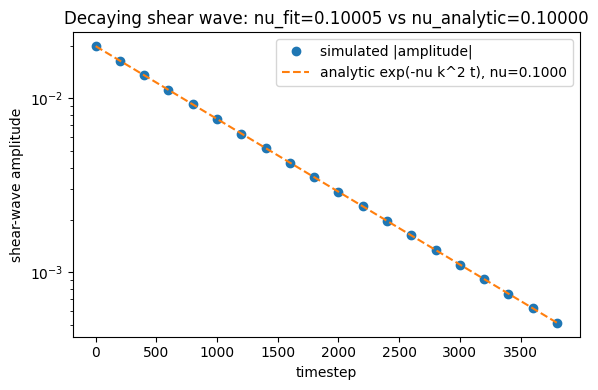

In [3]:
nx, ny = 20, 64
U0 = 0.02
tau = 0.8
nu_analytic = (tau - 0.5) / 3.0
k = 2 * np.pi / ny

y = np.arange(ny)
ux = U0 * np.sin(k * y)[None, :] * np.ones((nx, 1))
uy = np.zeros((nx, ny))
rho = np.ones((nx, ny))
f = lb.equilibrium(rho, ux, uy)

n_steps = 4000
sample_every = 200
times, amps = [], []
for step in range(n_steps):
    f = lb.collide(f, tau)
    f = lb.stream(f)
    if step % sample_every == 0:
        _, ux_m, _ = lb.moments(f)
        # project the (x-averaged) profile onto sin(k*y) to extract the mode amplitude
        profile = ux_m.mean(axis=0)
        A = 2 * np.mean(profile * np.sin(k * y))
        times.append(step)
        amps.append(A)

times = np.array(times, dtype=float)
amps = np.array(amps)
slope, intercept = np.polyfit(times, np.log(np.abs(amps)), 1)
nu_fit = -slope / k**2
rel_err = abs(nu_fit - nu_analytic) / nu_analytic
print(f'nu analytic (Chapman-Enskog) = {nu_analytic:.6f}')
print(f'nu fit (from decay rate)     = {nu_fit:.6f}')
print(f'relative error: {rel_err:.2e}')
assert rel_err < 0.01, 'measured shear-wave decay rate does not match the Chapman-Enskog viscosity'
print('PASS: shear-wave decay rate matches nu = (tau - 1/2)/3.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(times, np.abs(amps), 'o', label='simulated |amplitude|')
ax.semilogy(times, np.abs(amps[0]) * np.exp(-nu_analytic * k**2 * times), '--',
            label=f'analytic exp(-nu k^2 t), nu={nu_analytic:.4f}')
ax.set_xlabel('timestep')
ax.set_ylabel('shear-wave amplitude')
ax.set_title(f'Decaying shear wave: nu_fit={nu_fit:.5f} vs nu_analytic={nu_analytic:.5f}')
ax.legend()
fig.tight_layout()
fig.savefig('media/shear_wave_decay.png', dpi=150)
plt.show()

# Phase 2: Boundary Conditions & Solver

Validates `boundary.py` and `solver.py` two ways:

1. **Halfway bounce-back + Guo forcing**: a body-force-driven channel
   (periodic in x, bounce-back walls in y) should reach the analytic
   parabolic Poiseuille profile at steady state. Bounce-back at a
   single-cell-thick solid row effectively places the no-slip wall
   *halfway* between the solid node and its fluid neighbor, so the
   analytic profile uses an effective channel height `H = ny - 2` with
   wall locations at `y = 0.5` and `y = ny - 1.5`, not the raw grid
   extent.
2. **Zou-He moving lid**: confirms the prescribed lid velocity is
   recovered *exactly* at the boundary nodes (to machine precision, not
   just approximately) -- something plain bounce-back structurally can't
   do, since it only ever enforces zero velocity.

In [4]:
import boundary as bc
import solver as sv

## Poiseuille flow: bounce-back walls + Guo body-force forcing

max relative error vs. analytic Poiseuille profile: 4.25e-04
PASS: bounce-back + Guo forcing reproduces the analytic Poiseuille profile.


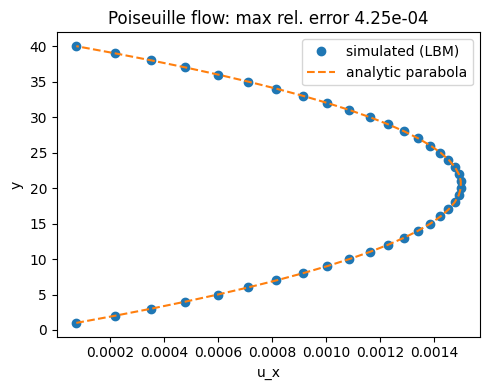

In [5]:
nx, ny = 4, 42
mask = np.ones((nx, ny), dtype=bool)
mask[:, 0] = False
mask[:, -1] = False

tau = 0.9
nu = (tau - 0.5) / 3.0
Fx = 1e-6
H = ny - 2  # effective channel height for halfway bounce-back

rho = np.ones((nx, ny))
f = lb.equilibrium(rho, np.zeros((nx, ny)), np.zeros((nx, ny)))

n_steps = 40000
for _ in range(n_steps):
    f = sv.step(f, tau, mask=mask, forcing=(Fx, 0.0))

_, ux_f, _ = lb.moments(f)
u_profile = ux_f.mean(axis=0)  # average over x (periodic -> should already be x-uniform)

y = np.arange(ny)
yp = y - 0.5
u_analytic = Fx / (2 * nu) * yp * (H - yp)

fluid_rows = np.where(mask[0])[0]
rel_err = np.abs(u_profile[fluid_rows] - u_analytic[fluid_rows]).max() / u_analytic[fluid_rows].max()
print(f'max relative error vs. analytic Poiseuille profile: {rel_err:.2e}')
assert rel_err < 0.01, 'steady-state channel profile does not match the analytic Poiseuille parabola'
print('PASS: bounce-back + Guo forcing reproduces the analytic Poiseuille profile.')

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(u_profile[fluid_rows], y[fluid_rows], 'o', label='simulated (LBM)')
ax.plot(u_analytic[fluid_rows], y[fluid_rows], '--', label='analytic parabola')
ax.set_xlabel('u_x'); ax.set_ylabel('y')
ax.set_title(f'Poiseuille flow: max rel. error {rel_err:.2e}')
ax.legend()
fig.tight_layout()
fig.savefig('media/poiseuille_profile.png', dpi=150)
plt.show()

## Zou-He moving lid: exact prescribed velocity

In [6]:
nx, ny = 30, 30
mask = np.ones((nx, ny), dtype=bool)
mask[0, :] = False
mask[-1, :] = False
mask[:, 0] = False
# top row (ny-1) is left fluid; the Zou-He lid BC is applied there instead of bounce-back.

tau = 0.8
U_lid = 0.1
rho = np.ones((nx, ny))
f = lb.equilibrium(rho, np.zeros((nx, ny)), np.zeros((nx, ny)))

for _ in range(500):
    f = sv.step(f, tau, mask=mask, moving_wall=(ny - 1, U_lid))

_, ux_f, uy_f = lb.moments(f)
ux_err = np.abs(ux_f[:, -1] - U_lid).max()
uy_err = np.abs(uy_f[:, -1]).max()
print(f'max |u_x - U_lid| at lid row: {ux_err:.2e}')
print(f'max |u_y| at lid row (no-penetration): {uy_err:.2e}')
assert ux_err < 1e-12 and uy_err < 1e-12, 'Zou-He should recover the prescribed lid velocity exactly'
print('PASS: Zou-He recovers the exact prescribed lid velocity, not just approximately.')

max |u_x - U_lid| at lid row: 2.78e-17
max |u_y| at lid row (no-penetration): 1.39e-17
PASS: Zou-He recovers the exact prescribed lid velocity, not just approximately.
